# Simulador de Saúde Mental e Risco de Depressão para Adolescentes

Este simulador utiliza o modelo de Machine Learning (`best_model.pkl` - Random Forest) e o padronizador (`scaler.pkl`) em conjunto com um **Sistema de Indicadores Clínicos Híbridos**.

## Sistema de Indicadores Clínicos (Escala de 0 a 10)
Para ir além de uma probabilidade estatística crua (que é conservadora devido aos poucos casos positivos na base), criamos três índices comportamentais explicativos:
1. **Qualidade de Vida (QV):** Combina horas de sono, desempenho acadêmico, atividade física e nível de interação social. *Quanto maior, melhor.*
2. **Dependência Digital (DD):** Combina horas diárias de redes sociais, uso de celular antes de dormir e vício autodeclarado. *Quanto maior, mais prejudicial.*
3. **Sobrecarga Psicológica (SP):** Combina os níveis autodeclarados de estresse e ansiedade. *Quanto maior, mais crítico.*

## Índice de Risco Geral (0% a 100%)
O **Risco Geral** é calculado pela combinação ponderada de:
- 40% da Predição de IA do modelo de Machine Learning.
- 40% da Sobrecarga Psicológica.
- 10% da Dependência Digital.
- 10% do inverso da Qualidade de Vida (Perda de QV).

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

## 1. Carregamento dos Modelos

In [26]:
try:
    model = joblib.load('../3-MachineLearning/best_model.pkl')
    scaler = joblib.load('../3-MachineLearning/scaler.pkl')
    print("Sucesso! Modelo Random Forest e Scaler carregados.")
except FileNotFoundError:
    print("Erro: Certifique-se de executar o notebook 'Treino-ML.ipynb' primeiro para gerar os arquivos correspondentes.")

Sucesso! Modelo Random Forest e Scaler carregados.


## 2. Função de Pré-processamento e Cálculo de Indicadores

In [27]:
def calcular_indicadores(row):
    # 1. Qualidade de Vida (0 a 10)
    score_sono = min(row['horas_sono'] / 9.0 * 10, 10)
    score_fisico = min(row['atividade_fisica'] / 2.0 * 10, 10)
    score_social = {'baixo': 2.0, 'medio': 6.0, 'alto': 10.0}.get(row['nivel_interacao_social'], 5.0)
    score_academico = min(row['desempenho_academico'] / 4.0 * 10, 10)
    qv = (score_sono + score_fisico + score_social + score_academico) / 4.0
    
    # 2. Dependência Digital (0 a 10)
    score_redes = min(row['horas_diarias_redes_sociais'] / 8.0 * 10, 10)
    score_tela = min(row['tempo_tela_antes_sono'] / 3.0 * 10, 10)
    score_vicio = row['nivel_vicio'] # Já está na escala 1 a 10
    dd = (score_redes + score_tela + score_vicio) / 3.0
    
    # 3. Sobrecarga Psicológica (0 a 10)
    sp = (row['nivel_estresse'] + row['nivel_ansiedade']) / 2.0
    
    return pd.Series({'Qualidade_Vida': round(qv, 2), 'Dependencia_Digital': round(dd, 2), 'Sobrecarga_Psicologica': round(sp, 2)})

def preprocess_input(raw_data, scaler_obj):
    df_in = pd.DataFrame(raw_data)
    
    df_in['genero'] = df_in['genero'].map({'masculino': 0, 'feminino': 1})
    df_in['nivel_interacao_social'] = df_in['nivel_interacao_social'].map({'baixo': 0, 'medio': 1, 'alto': 2})
    
    for plat in ['Ambas', 'Instagram', 'TikTok']:
        col_name = f'plataforma_{plat}'
        df_in[col_name] = (df_in['uso_plataforma'] == plat).astype(int)
        
    df_in = df_in.drop(columns=['uso_plataforma'])
    
    features_order = [
        'idade', 'genero', 'horas_diarias_redes_sociais', 'horas_sono', 
        'tempo_tela_antes_sono', 'desempenho_academico', 'atividade_fisica', 
        'nivel_interacao_social', 'nivel_estresse', 'nivel_ansiedade', 'nivel_vicio',
        'plataforma_Ambas', 'plataforma_Instagram', 'plataforma_TikTok'
    ]
    df_in = df_in[features_order]
    
    cols_to_scale = [
        'idade', 'horas_diarias_redes_sociais', 'horas_sono', 
        'tempo_tela_antes_sono', 'desempenho_academico', 
        'atividade_fisica', 'nivel_estresse', 'nivel_ansiedade', 'nivel_vicio'
    ]
    df_in[cols_to_scale] = scaler_obj.transform(df_in[cols_to_scale])
    
    return df_in

## 3. Criação dos Perfis de Teste (Personas)

In [32]:
personas = [
    {
        'nome': 'Pedro',
        'idade': 16,
        'genero': 'masculino',
        'horas_diarias_redes_sociais': 1.5,
        'uso_plataforma': 'Instagram',
        'horas_sono': 8.0,
        'tempo_tela_antes_sono': 0.5,
        'desempenho_academico': 3.8,
        'atividade_fisica': 1.5,
        'nivel_interacao_social': 'alto',
        'nivel_estresse': 2,
        'nivel_ansiedade': 2,
        'nivel_vicio': 1
    },
    {
        'nome': 'Ana',
        'idade': 17,
        'genero': 'feminino',
        'horas_diarias_redes_sociais': 8.0,
        'uso_plataforma': 'Instagram',
        'horas_sono': 4.5, # Ajustado para privação crítica de sono
        'tempo_tela_antes_sono': 6.0,
        'desempenho_academico': 2.0,
        'atividade_fisica': 0.1,
        'nivel_interacao_social': 'baixo',
        'nivel_estresse': 9,
        'nivel_ansiedade': 10,
        'nivel_vicio': 8
    },
    {
        'nome': 'Lucas',
        'idade': 15,
        'genero': 'masculino',
        'horas_diarias_redes_sociais': 5.5,
        'uso_plataforma': 'Ambas',
        'horas_sono': 5.0,
        'tempo_tela_antes_sono': 2.5,
        'desempenho_academico': 2.7,
        'atividade_fisica': 0.5,
        'nivel_interacao_social': 'medio',
        'nivel_estresse': 6,
        'nivel_ansiedade': 5,
        'nivel_vicio': 7
    },
    {
        'nome': 'Mariana',
        'idade': 18,
        'genero': 'feminino',
        'horas_diarias_redes_sociais': 3.5,
        'uso_plataforma': 'Instagram',
        'horas_sono': 5.5,
        'tempo_tela_antes_sono': 1.5,
        'desempenho_academico': 3.9,
        'atividade_fisica': 0.8,
        'nivel_interacao_social': 'medio',
        'nivel_estresse': 8,
        'nivel_ansiedade': 8,
        'nivel_vicio': 4
    }
]

df_raw_personas = pd.DataFrame(personas)
df_features = df_raw_personas.drop(columns=['nome'])

# Aplicar cálculo dos sub-indicadores
df_indices = df_features.apply(calcular_indicadores, axis=1)
df_dashboard = pd.concat([df_raw_personas[['nome']], df_indices], axis=1)
df_dashboard

,nome,Qualidade_Vida,Dependencia_Digital,Sobrecarga_Psicologica
0,Pedro,8.97,1.51,2.0
1,Ana,3.12,9.33,9.5
2,Lucas,5.20,7.40,5.5
3,Mariana,6.47,4.46,8.0


## 4. Rodando Predição de ML e Calculando Risco Geral

In [33]:
# Pré-processamento e predição com o modelo
X_scaled = preprocess_input(df_features, scaler)
probabilidades_ia = model.predict_proba(X_scaled)[:, 1]

df_dashboard['Prob_IA'] = probabilidades_ia * 100

# Cálculo do Índice de Risco Geral (0% a 100%)
# Fórmula: (Prob_IA * 0.4) + (Sobrecarga_Psicologica * 10 * 0.4) + ((10 - Qualidade_Vida) * 10 * 0.1) + (Dependencia_Digital * 10 * 0.1)
df_dashboard['Risco_Geral_Percentual'] = (
    (df_dashboard['Prob_IA'] * 0.40) + 
    (df_dashboard['Sobrecarga_Psicologica'] * 10.0 * 0.40) + 
    ((10.0 - df_dashboard['Qualidade_Vida']) * 10.0 * 0.10) + 
    (df_dashboard['Dependencia_Digital'] * 10.0 * 0.10)
)

# Classificação do Risco Geral
df_dashboard['Risco_Geral_Percentual'] = df_dashboard['Risco_Geral_Percentual'].round(1)
df_dashboard['Classificacao_Risco'] = df_dashboard['Risco_Geral_Percentual'].apply(
    lambda x: 'Baixo Risco' if x < 30 else ('Risco Moderado' if x < 70 else 'Risco Crítico')
)

df_dashboard[['nome', 'Qualidade_Vida', 'Dependencia_Digital', 'Sobrecarga_Psicologica', 'Prob_IA', 'Risco_Geral_Percentual', 'Classificacao_Risco']]

,nome,Qualidade_Vida,Dependencia_Digital,Sobrecarga_Psicologica,Prob_IA,Risco_Geral_Percentual,Classificacao_Risco
0,Pedro,8.97,1.51,2.0,0.0,10.5,Baixo Risco
1,Ana,3.12,9.33,9.5,61.0,78.6,Risco Crítico
2,Lucas,5.20,7.40,5.5,1.0,34.6,Risco Moderado
3,Mariana,6.47,4.46,8.0,7.0,42.8,Risco Moderado


## 5. Visualização em Painel Comparativo (Dashboard)

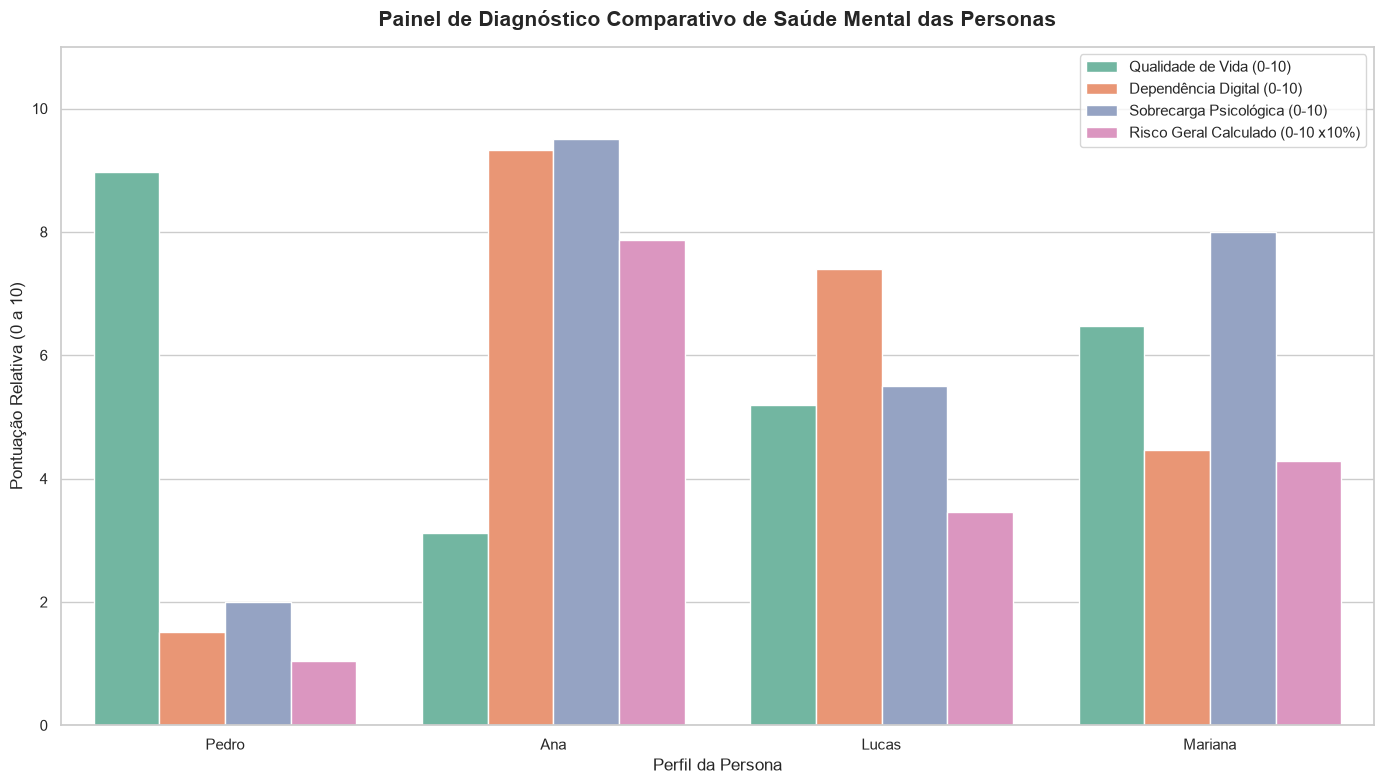

In [34]:
# Transformar para formato longo (long format) para facilitar a plotagem no Seaborn
df_plot = df_dashboard.melt(
    id_vars=['nome', 'Classificacao_Risco'], 
    value_vars=['Qualidade_Vida', 'Dependencia_Digital', 'Sobrecarga_Psicologica', 'Risco_Geral_Percentual'],
    var_name='Indicador', 
    value_name='Pontuacao'
)

# Ajustar a escala do Risco Geral de 0-100 para 0-10 apenas no gráfico para comparação visual
df_plot.loc[df_plot['Indicador'] == 'Risco_Geral_Percentual', 'Pontuacao'] /= 10.0

# Renomear indicadores para português elegante nos gráficos
indicador_nomes = {
    'Qualidade_Vida': 'Qualidade de Vida (0-10)',
    'Dependencia_Digital': 'Dependência Digital (0-10)',
    'Sobrecarga_Psicologica': 'Sobrecarga Psicológica (0-10)',
    'Risco_Geral_Percentual': 'Risco Geral Calculado (0-10 x10%)'
}
df_plot['Indicador'] = df_plot['Indicador'].map(indicador_nomes)

# Plotando o gráfico de barras comparativo
plt.figure(figsize=(14, 8))
sns.barplot(data=df_plot, x='nome', y='Pontuacao', hue='Indicador', palette='Set2')
plt.title('Painel de Diagnóstico Comparativo de Saúde Mental das Personas', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Pontuação Relativa (0 a 10)', fontsize=12)
plt.xlabel('Perfil da Persona', fontsize=12)
plt.ylim(0, 11)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

## 6. Feedbacks Clínicos e Orientações formatadas

In [31]:
def obter_recomendacao(status, risco_val):
    if status == 'Baixo Risco':
        return "Paciente estável. A rotina apresenta bons fatores protetivos (sono regulado e atividade física). Monitoramento padrão recomendável."
    elif status == 'Risco Moderado':
        return "Atenção Necessária. Identificados sintomas iniciais de sobrecarga mental ou alto tempo de exposição digital. Recomenda-se higiene do sono e controle parental ativo no uso de telas."
    else:
        return "Alerta Crítico. Paciente apresenta alto índice de sobrecarga emocional, privação de sono acentuada e forte dependência de telas. Sugere-se encaminhamento clínico especializado imediato (psicologia/psiquiatria)."

for idx, row in df_dashboard.iterrows():
    print(f"=== Diagnóstico Integrado: {row['nome']} ===")
    print(f"- Status Geral: {row['Classificacao_Risco']} ({row['Risco_Geral_Percentual']}%)")
    print(f"- Qualidade de Vida (0-10): {row['Qualidade_Vida']} | Dependência Digital: {row['Dependencia_Digital']}")
    print(f"- Sobrecarga Psicológica (0-10): {row['Sobrecarga_Psicologica']}")
    print(f"- Recomendação de Ação: {obter_recomendacao(row['Classificacao_Risco'], row['Risco_Geral_Percentual'])}")
    print("-" * 90 + "\n")

=== Diagnóstico Integrado: Pedro (O Equilibrado) ===
- Status Geral: Baixo Risco (10.5%)
- Qualidade de Vida (0-10): 8.97 | Dependência Digital: 1.51
- Sobrecarga Psicológica (0-10): 2.0
- Recomendação de Ação: Paciente estável. A rotina apresenta bons fatores protetivos (sono regulado e atividade física). Monitoramento padrão recomendável.
------------------------------------------------------------------------------------------

=== Diagnóstico Integrado: Ana (Conectada e Sob Pressão) ===
- Status Geral: Risco Crítico (78.6%)
- Qualidade de Vida (0-10): 3.12 | Dependência Digital: 9.33
- Sobrecarga Psicológica (0-10): 9.5
- Recomendação de Ação: Alerta Crítico. Paciente apresenta alto índice de sobrecarga emocional, privação de sono acentuada e forte dependência de telas. Sugere-se encaminhamento clínico especializado imediato (psicologia/psiquiatria).
------------------------------------------------------------------------------------------

=== Diagnóstico Integrado: Lucas (O Gamer